In [1]:
# Base model imports
import sys
sys.path.append('../multi_nutrient_model')
from multi_nutrient_model import (
    ref_parameters as ref_parameters_base,
    perturbation_dynamics as perturbation_dynamics_base,
    I0 as I0_base,
    PARAMETER_NAMES as PARAMETER_NAMES_base,
    equation as equation_base,
    change_parameters as change_parameters_base,
    TAU_INS,
)

# Extended model imports
from multi_nutrient_model_glucagon import (
    ref_parameters as ref_parameters_ext,
    perturbation_dynamics as perturbation_dynamics_ext,
    I0 as I0_ext,
    PARAMETER_NAMES as PARAMETER_NAMES_ext,
    equation as equation_ext,
    change_parameters as change_parameters_ext,
    GCG0
)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import fsolve

# Set plotting style
plt.rcParams.update({'font.size': 12, 'font.family': 'Arial'})

## Glucose Response Comparison: Base vs Glucagon Model

Compare glucose as a function of energy expenditure and insulin (R_insulin) for the base and glucagon models.

In [2]:
# Common parameters
K_i_ketogenesis = 0.2

# Time for dynamics to reach steady state
time_dyn = np.linspace(0, 100, 100)

# Steady state tolerance
tol = 1e-4

def compute_steady_states(model_type, param_name, param_range, K_i_ketogenesis=0.2, 
                          time_dyn=time_dyn, tol=1e-4, relative=True):
    """
    Compute steady states for varying a parameter.
    
    Parameters
    ----------
    model_type : str
        'base' or 'extended'
    param_name : str
        Name of the parameter to vary (e.g., 'v_energy', 'R_insulin')
    param_range : array
        Array of parameter values (multipliers if relative=True, absolute if relative=False)
    K_i_ketogenesis : float
        Ketogenesis inhibition constant
    time_dyn : array
        Time points for dynamics simulation
    tol : float
        Tolerance for steady state convergence
    relative : bool
        If True, param_range values are multipliers of the baseline value.
        If False, param_range values are absolute parameter values.
        
    Returns
    -------
    DataFrame with columns: perturbation, Glucose, Insulin, Glucagon, steady, failed, model
    """
    if model_type == 'base':
        ref_parameters = ref_parameters_base
        perturbation_dynamics = perturbation_dynamics_base
        PARAMETER_NAMES = PARAMETER_NAMES_base
        equation = equation_base
        change_parameters = change_parameters_base
        I0 = I0_base
        model_label = 'Base'
    elif model_type == 'extended':
        ref_parameters = ref_parameters_ext
        perturbation_dynamics = perturbation_dynamics_ext
        PARAMETER_NAMES = PARAMETER_NAMES_ext
        equation = equation_ext
        change_parameters = change_parameters_ext
        I0 = I0_ext
        model_label = 'Glucagon'
    else:
        raise ValueError(f"Unknown model_type: {model_type}")
    
    records = []
    p_base = ref_parameters(K_i_ketogenesis=K_i_ketogenesis)
    base_value = p_base[PARAMETER_NAMES.index(param_name)]
    
    for val in param_range:
        # Compute actual parameter value
        if relative:
            actual_value = val * base_value
        else:
            actual_value = val
        
        # Use change_parameters to modify the parameter
        p = change_parameters(p_base.copy(), [actual_value], [param_name])
        
        try:
            X_trace, _ = perturbation_dynamics(time_dyn, 1.0, p=p)
            failed = False
        except Exception:
            records.append({
                'perturbation': val,
                'Glucose': np.nan,
                'Insulin': np.nan,
                'Glucagon': np.nan,
                'steady': False,
                'failed': True,
                'model': model_label
            })
            continue
        
        x_end = X_trace.iloc[-1, :-1].values
        
        dx = equation(x_end, 1.0, p)
        dyn_residual = np.max(np.abs(dx))
        
        if dyn_residual >= tol:
            def ss_eq(x):
                return equation(x, 1.0, p)
            
            x_ss, info, ier, mesg = fsolve(ss_eq, x_end, full_output=True, xtol=tol)
            ss_residual = np.max(np.abs(info['fvec']))
            if ier == 1 and np.all(x_ss >= 0) and ss_residual < tol:
                x_end = x_ss
                steady = True
            else:
                steady = False
        else:
            steady = True
        
        if model_type == 'extended':
            glucagon = x_end[6] / GCG0
        else:
            glucagon = np.nan
        
        records.append({
            'perturbation': val,
            'Glucose': x_end[1] * 6,  # G is index 1, convert to mM
            'Insulin': x_end[4] / I0,  # I is index 4, normalize to basal
            'Glucagon': glucagon,
            'steady': steady,
            'failed': False,
            'model': model_label
        })
    
    df = pd.DataFrame(records)
    df = df.loc[~df['failed'] & df['steady']].reset_index(drop=True)
    return df

print("Function defined successfully")

Function defined successfully


## Compute Steady States

Compute glucose response to energy expenditure and insulin sensitivity variations for both models.

In [3]:
# Perturbation range (relative to basal)
perturbation_range = np.logspace(np.log10(1/3), np.log10(3), 50)

print(f"Perturbation range: {perturbation_range.min():.3f}x to {perturbation_range.max():.3f}x basal")

# Compute steady states for energy expenditure (v_energy)
print("\nComputing energy expenditure response...")
df_energy_base = compute_steady_states('base', 'v_energy', perturbation_range, K_i_ketogenesis=K_i_ketogenesis)
print(f"✓ Base model: {len(df_energy_base)} valid steady states")

df_energy_ext = compute_steady_states('extended', 'v_energy', perturbation_range, K_i_ketogenesis=K_i_ketogenesis)
print(f"✓ Glucagon model: {len(df_energy_ext)} valid steady states")

df_energy = pd.concat([df_energy_base, df_energy_ext], axis=0, ignore_index=True)

# Compute steady states for insulin infusion (R_insulin)
# R_insulin baseline is 0, so use absolute values
print("\nComputing insulin infusion response...")
insulin_range = np.linspace(0, 3 * I0_base / TAU_INS, 50)  # Absolute insulin infusion values

df_insulin_base = compute_steady_states('base', 'R_insulin', insulin_range, K_i_ketogenesis=K_i_ketogenesis, relative=False)
print(f"✓ Base model: {len(df_insulin_base)} valid steady states")

df_insulin_ext = compute_steady_states('extended', 'R_insulin', insulin_range, K_i_ketogenesis=K_i_ketogenesis, relative=False)
print(f"✓ Glucagon model: {len(df_insulin_ext)} valid steady states")

df_insulin = pd.concat([df_insulin_base, df_insulin_ext], axis=0, ignore_index=True)

Perturbation range: 0.333x to 3.000x basal

Computing energy expenditure response...
✓ Base model: 50 valid steady states
✓ Glucagon model: 50 valid steady states

Computing insulin infusion response...
✓ Base model: 50 valid steady states
✓ Glucagon model: 50 valid steady states


## Comparison Plots

Side-by-side plots showing glucose response to energy expenditure and insulin sensitivity for base vs glucagon models.

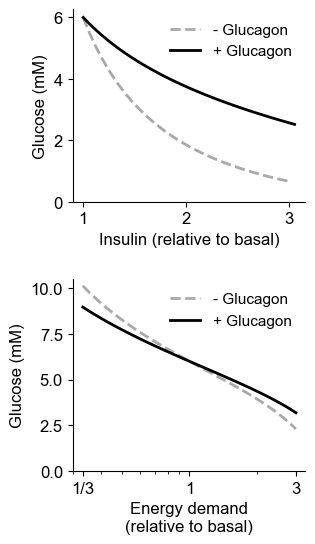

In [4]:
# Create side-by-side comparison plots
fig, axes = plt.subplots(2, 1, figsize=(3, 6), gridspec_kw={'wspace': 0.3, 'hspace': 0.4})

# Plot 1: Glucose vs Steady State Insulin
ax1 = axes[0]
for model, label, color, linestyle in [('Base', '- Glucagon', 'darkgrey', '--'), ('Glucagon', '+ Glucagon', 'black', '-')]:
    df_model = df_insulin[df_insulin['model'] == model]
    ax1.plot(df_model['Insulin'], df_model['Glucose'], 
             color=color, linestyle=linestyle, linewidth=2, label=label)

ax1.set_xlabel("Insulin (relative to basal)")
ax1.set_ylabel("Glucose (mM)")
ax1.legend(frameon=False, fontsize=11)
ax1.set_ylim(bottom=0)

# Plot 2: Glucose vs Energy Expenditure
ax2 = axes[1]
for model, label, color, linestyle in [('Base', '- Glucagon', 'darkgrey', '--'), ('Glucagon', '+ Glucagon', 'black', '-')]:
    df_model = df_energy[df_energy['model'] == model]
    ax2.plot(df_model['perturbation'], df_model['Glucose'], 
             color=color, linestyle=linestyle, linewidth=2, label=label)

ax2.set_xscale('log')
ax2.set_xticks([1/3, 1, 3])
ax2.set_xticklabels(['1/3', '1', '3'])
ax2.set_xlim(1/3 * 0.9, 3 * 1.1)
ax2.set_xlabel("Energy demand\n(relative to basal)")
ax2.set_ylabel("Glucose (mM)")
ax2.legend(frameon=False, fontsize=11)
ax2.set_ylim(bottom=0)

sns.despine()
plt.savefig('./output/glucose_energy_insulin_comparison.svg', bbox_inches='tight')
plt.show()


In [5]:
# Glucagon Regulatory Effect Knockout Comparison
# Compare WT (full glucagon model) vs KO (individual glucagon effect knockouts)

def compute_steady_states_with_params(model_type, param_name, param_range, label,
                                       K_i_ketogenesis=0.2, time_dyn=time_dyn, tol=1e-4, 
                                       relative=True, **extra_params):
    """
    Compute steady states with custom parameter modifications.
    
    Parameters
    ----------
    extra_params : dict
        Additional parameters to pass to ref_parameters (e.g., glucagon_action_glycogenolysis=False)
    """
    if model_type == 'extended':
        PARAMETER_NAMES = PARAMETER_NAMES_ext
        equation = equation_ext
        change_parameters = change_parameters_ext
        perturbation_dynamics = perturbation_dynamics_ext
        I0 = I0_ext
        
        # Create reference parameters with any knockouts
        p_base = ref_parameters_ext(K_i_ketogenesis=K_i_ketogenesis, **extra_params)
    else:
        raise ValueError("Only extended model supported for KO analysis")
    
    records = []
    base_value = p_base[PARAMETER_NAMES.index(param_name)]
    
    for val in param_range:
        if relative:
            actual_value = val * base_value
        else:
            actual_value = val
        
        p = change_parameters(p_base.copy(), [actual_value], [param_name])
        
        try:
            X_trace, _ = perturbation_dynamics(time_dyn, 1.0, p=p)
            failed = False
        except Exception:
            records.append({
                'perturbation': val,
                'Glucose': np.nan,
                'Insulin': np.nan,
                'Glucagon': np.nan,
                'steady': False,
                'failed': True,
                'model': label
            })
            continue
        
        x_end = X_trace.iloc[-1, :-1].values
        dx = equation(x_end, 1.0, p)
        dyn_residual = np.max(np.abs(dx))
        
        if dyn_residual >= tol:
            def ss_eq(x):
                return equation(x, 1.0, p)
            
            x_ss, info, ier, mesg = fsolve(ss_eq, x_end, full_output=True, xtol=tol)
            ss_residual = np.max(np.abs(info['fvec']))
            if ier == 1 and np.all(x_ss >= 0) and ss_residual < tol:
                x_end = x_ss
                steady = True
            else:
                steady = False
        else:
            steady = True
        
        glucagon = x_end[6] / GCG0
        
        records.append({
            'perturbation': val,
            'Glucose': x_end[1] * 6,
            'Insulin': x_end[4] / I0,
            'Glucagon': glucagon,
            'steady': steady,
            'failed': False,
            'model': label
        })
    
    df = pd.DataFrame(records)
    df = df.loc[~df['failed'] & df['steady']].reset_index(drop=True)
    return df

# Define glucagon knockouts to test
glucagon_knockouts = [
    {'name': 'Gluconeogenesis', 'param': 'glucagon_action_gluconeogenesis', 'short': 'GNG'},
    {'name': 'Glycogenolysis', 'param': 'glucagon_action_glycogenolysis', 'short': 'GLY'},
    {'name': 'Ketogenesis', 'param': 'glucagon_action_ketogenesis', 'short': 'KG'},
]

print("Computing knockout steady states...")

# Compute WT (all glucagon effects active) - use existing df_energy_ext and df_insulin_ext
# But relabel them
df_energy_wt = df_energy_ext.copy()
df_energy_wt['model'] = 'WT'
df_insulin_wt = df_insulin_ext.copy()
df_insulin_wt['model'] = 'WT'

# Compute KO for each glucagon effect
ko_energy_dfs = {}
ko_insulin_dfs = {}

for ko in glucagon_knockouts:
    print(f"  Computing {ko['name']} KO...")
    
    # Create kwargs for knockout
    ko_params = {ko['param']: False}
    
    # Energy perturbation
    df_ko_energy = compute_steady_states_with_params(
        'extended', 'v_energy', perturbation_range, 
        label=f"{ko['short']} KO",
        K_i_ketogenesis=K_i_ketogenesis,
        **ko_params
    )
    ko_energy_dfs[ko['short']] = df_ko_energy
    
    # Insulin perturbation
    df_ko_insulin = compute_steady_states_with_params(
        'extended', 'R_insulin', insulin_range, 
        label=f"{ko['short']} KO",
        K_i_ketogenesis=K_i_ketogenesis,
        relative=False,
        **ko_params
    )
    ko_insulin_dfs[ko['short']] = df_ko_insulin

print("✓ All knockout computations complete")

Computing knockout steady states...
  Computing Gluconeogenesis KO...
  Computing Glycogenolysis KO...
  Computing Ketogenesis KO...
✓ All knockout computations complete


## Glucagon Regulatory Effect Knockouts

Compare WT (full glucagon model) vs individual knockouts of glucagon regulatory effects on:
- Gluconeogenesis (K_a_gluconeogenesis)
- Glycogenolysis (K_a_glycogenolysis)  
- Ketogenesis (K_a_ketogenesis)

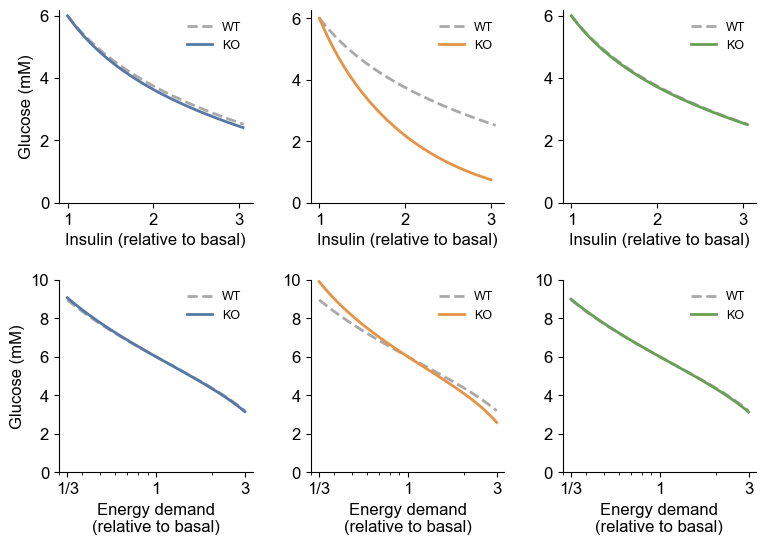

In [6]:
# Create side-by-side comparison plots: WT vs each KO
# Row 1: Insulin-induced hypoglycemia (3 subplots for 3 knockouts)
# Row 2: Energy expenditure perturbation (3 subplots for 3 knockouts)

fig, axes = plt.subplots(2, 3, figsize=(9, 6), gridspec_kw={'wspace': 0.3, 'hspace': 0.4})

# Muted colors for KO lines
ko_colors = {'GNG': '#5778a4', 'GLY': '#e49444', 'KG': '#6a9f58'}  # muted blue, orange, green
ko_labels = {'GNG': 'Gluconeogenesis KO', 'GLY': 'Glycogenolysis KO', 'KG': 'Ketogenesis KO'}

# Row 1: Insulin-induced hypoglycemia
for i, ko in enumerate(glucagon_knockouts):
    ax = axes[0, i]
    
    # Plot WT (dashed grey)
    ax.plot(df_insulin_wt['Insulin'], df_insulin_wt['Glucose'], 
            color='darkgrey', linestyle='--', linewidth=2, label='WT')
    
    # Plot KO (solid colored)
    df_ko = ko_insulin_dfs[ko['short']]
    ax.plot(df_ko['Insulin'], df_ko['Glucose'], 
            color=ko_colors[ko['short']], linestyle='-', linewidth=2, label='KO')
    
    ax.set_xlabel("Insulin (relative to basal)")
    if i == 0:
        ax.set_ylabel("Glucose (mM)")
    ax.legend(frameon=False, fontsize=9)
    ax.set_ylim(bottom=0)

# Row 2: Energy expenditure
for i, ko in enumerate(glucagon_knockouts):
    ax = axes[1, i]
    
    # Plot WT (dashed grey)
    ax.plot(df_energy_wt['perturbation'], df_energy_wt['Glucose'], 
            color='darkgrey', linestyle='--', linewidth=2, label='WT')
    
    # Plot KO (solid colored)
    df_ko = ko_energy_dfs[ko['short']]
    ax.plot(df_ko['perturbation'], df_ko['Glucose'], 
            color=ko_colors[ko['short']], linestyle='-', linewidth=2, label='KO')
    
    ax.set_xscale('log')
    ax.set_xticks([1/3, 1, 3])
    ax.set_xticklabels(['1/3', '1', '3'])
    ax.set_xlim(1/3 * 0.9, 3 * 1.1)
    ax.set_xlabel("Energy demand\n(relative to basal)")
    if i == 0:
        ax.set_ylabel("Glucose (mM)")
    ax.legend(frameon=False, fontsize=9)
    ax.set_ylim(0, 10)

sns.despine()
plt.savefig('./output/glucagon_knockout_comparison.svg', bbox_inches='tight')
plt.show()
